# Модуль 17. Коллаборативная фильтрация

Ноутбук к [модулю 17](https://drobyshevdev.github.io/lemma/modules/17-collaborative-filtering/).

Матрица взаимодействий, item-item CF, матричное разложение градиентным спуском, холодный старт и база «топ популярного». Только `numpy` и `matplotlib`.

**Читайте дважды:** сначала целиком, потом ломая.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(0)

# Синтетика с тремя кластерами вкуса и общей популярностью.
N_USERS, N_ITEMS, N_CLUST = 200, 45, 3
item_clust = np.repeat(np.arange(N_CLUST), N_ITEMS // N_CLUST)
item_clust = np.concatenate([item_clust, np.full(N_ITEMS - len(item_clust), N_CLUST - 1)])
user_clust = rng.integers(0, N_CLUST, N_USERS)
pop = rng.random(N_ITEMS) ** 3                         # у нескольких товаров высокая популярность

R = np.zeros((N_USERS, N_ITEMS))
for u in range(N_USERS):
    for i in range(N_ITEMS):
        p = 0.55 if item_clust[i] == user_clust[u] else 0.03
        p += 0.4 * pop[i]                              # популярное лайкают вне зависимости от вкуса
        R[u, i] = rng.random() < min(0.95, p)
print("матрица:", R.shape, " заполнена на %.0f%%" % (100 * R.mean()))

матрица: (200, 45)  заполнена на 30%


## 1. Item-item коллаборативная фильтрация

Похожесть товаров — косинус между столбцами матрицы: два товара похожи, если их лайкают одни и те же люди. Рекомендуем непросмотренное, ближайшее к тому, что пользователь уже любит.

In [2]:
def cosine_sim(M):
    norm = np.linalg.norm(M, axis=0, keepdims=True) + 1e-9
    U = M / norm
    return U.T @ U                                     # item-item косинусная близость

def recommend_cf(R, u, k=3):
    sim = cosine_sim(R)
    liked = np.where(R[u] > 0)[0]
    score = sim[liked].sum(0)                          # сумма похожестей на уже понравившееся
    score[R[u] > 0] = -1                               # не рекомендуем уже виденное
    return np.argsort(-score)[:k]

for u in [0, 1, 2]:
    liked = np.where(R[u] > 0)[0]
    rec = recommend_cf(R, u)
    print("пользователь %d (кластер %d): рекомендуем товары %s из кластеров %s"
          % (u, user_clust[u], rec.tolist(), item_clust[rec].tolist()))

пользователь 0 (кластер 2): рекомендуем товары [42, 3, 32] из кластеров [2, 0, 2]
пользователь 1 (кластер 1): рекомендуем товары [16, 26, 23] из кластеров [1, 1, 1]
пользователь 2 (кластер 1): рекомендуем товары [27, 23, 25] из кластеров [1, 1, 1]


Рекомендации садятся в кластер вкуса пользователя — система вывела его из совместных лайков, ничего не зная о содержании товара.

**Сломать.** Поднимите общую популярность (`pop ** 3 -> pop ** 1`) — рекомендации поплывут к популярному: оно похоже на всё сразу. Это смещение из раздела 4.

## 2. Матричное разложение

Сжимаем всех в короткие векторы: $R \approx U V^{\top}$. Факторы находит градиентный спуск, минимизируя ошибку на матрице. Оценка симпатии — скалярное произведение строк $U$ и $V$.

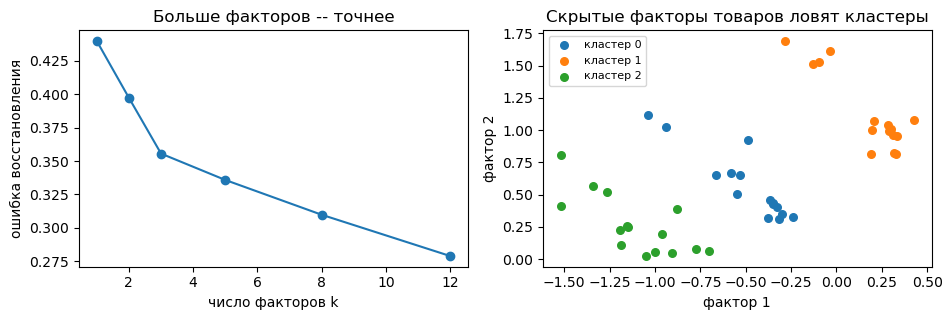

два фактора уже разносят кластеры вкуса по разным углам пространства


In [3]:
def matrix_factorize(R, k, steps=400, lr=0.02, reg=0.05, seed=0):
    g = np.random.default_rng(seed)
    U = g.normal(0, 0.1, (R.shape[0], k))
    V = g.normal(0, 0.1, (R.shape[1], k))
    for _ in range(steps):
        E = R - U @ V.T                                # ошибка на всех клетках
        U += lr * (E @ V - reg * U)
        V += lr * (E.T @ U - reg * V)
    return U, V

ks = [1, 2, 3, 5, 8, 12]
err = []
for k in ks:
    U, V = matrix_factorize(R, k)
    err.append(np.sqrt(np.mean((R - U @ V.T) ** 2)))

fig, axes = plt.subplots(1, 2, figsize=(9.5, 3.3))
axes[0].plot(ks, err, "o-"); axes[0].set_xlabel("число факторов k")
axes[0].set_ylabel("ошибка восстановления"); axes[0].set_title("Больше факторов -- точнее")

U, V = matrix_factorize(R, 2)                          # два фактора для картинки
for c in range(N_CLUST):
    m = item_clust == c
    axes[1].scatter(V[m, 0], V[m, 1], s=30, label="кластер %d" % c)
axes[1].set_title("Скрытые факторы товаров ловят кластеры")
axes[1].set_xlabel("фактор 1"); axes[1].set_ylabel("фактор 2"); axes[1].legend(fontsize=8)
plt.tight_layout(); plt.show()
print("два фактора уже разносят кластеры вкуса по разным углам пространства")

Скрытые факторы, которые никто не задавал, сами разложили товары по кластерам вкуса: спуск нашёл оси, вдоль которых поведение объясняется короче всего. Это эмбеддинги из модуля 9, выученные из лайков, а не из картинок.

**Сломать.** Уберите регуляризацию (`reg=0`) — на разреженной матрице факторы начнут запоминать шум, и кластеры на картинке расплывутся. Это переобучение из модуля 2.

## 3. Холодный старт

Новый пользователь ничего не лайкнул. Коллаборативной фильтрации не за что зацепиться — она выдаёт мусор. Спасает откат на популярное, пока лайки не накопятся.

In [4]:
cold = np.zeros(N_ITEMS)                               # новый пользователь: пустая строка
sim = cosine_sim(R)
cf_score = sim[np.where(cold > 0)[0]].sum(0) if cold.any() else np.zeros(N_ITEMS)
pop_score = R.sum(0)                                   # популярность = сколько всего лайков

print("CF для нового пользователя: сумма похожестей =", cf_score.sum(), "(рекомендовать нечего)")
print("откат на популярное -> топ-3 товара:", np.argsort(-pop_score)[:3].tolist())

CF для нового пользователя: сумма похожестей = 0.0 (рекомендовать нечего)
откат на популярное -> топ-3 товара: [38, 7, 22]


Пустая строка не даёт CF ни одного сигнала: рекомендация вырождается. Популярное — честный запасной ход, потому что не требует истории. Как только пользователь лайкнет несколько товаров, слово переходит к CF.

**Сломать.** Дайте новому пользователю один лайк и посмотрите, как CF сразу оживает: одного столбца похожести хватает, чтобы вытащить кластер.

## 4. Смещение к популярному

Популярный товар похож на всё и лезет всем. Проверим: бьёт ли CF тривиальную базу «рекомендовать топ популярного» на честной метрике. Прячем у каждого пользователя один лайк и смотрим, попадает ли он в топ-k рекомендаций (recall@k).

In [5]:
def recall_at_k(score_fn, k=5, seed=1):
    g = np.random.default_rng(seed); hits = 0; total = 0
    for u in range(N_USERS):
        liked = np.where(R[u] > 0)[0]
        if len(liked) < 2:
            continue
        held = g.choice(liked)                          # прячем один лайк
        train = R[u].copy(); train[held] = 0
        score = score_fn(u, train)
        score[train > 0] = -np.inf                      # не считаем уже виденное
        top = np.argsort(-score)[:k]
        hits += held in top; total += 1
    return hits / total

sim = cosine_sim(R)
def cf_fn(u, train): return sim[np.where(train > 0)[0]].sum(0)
def pop_fn(u, train): return R.sum(0).astype(float)

print("recall@5 -- коллаборативная фильтрация: %.3f" % recall_at_k(cf_fn))
print("recall@5 -- база 'топ популярного':      %.3f" % recall_at_k(pop_fn))

recall@5 -- коллаборативная фильтрация: 0.630
recall@5 -- база 'топ популярного':      0.295


CF обыгрывает популярное — но база не смешная: у неё приличный recall, потому что популярное и правда лайкают часто. Рекомендатель, который её не бьёт, не рекомендует, а пересказывает рейтинг. Это тривиальная база из модуля 1, посчитанная первой.

## Что дальше

В [модуле 18](https://drobyshevdev.github.io/lemma/programme/) — нейронные рекомендатели, ранжирование и метрики, и почему офлайн-метрика и онлайн-эффект расходятся: модель меняет данные, на которых её потом оценивают.